# Pumping Test

### Table of Contents

1. [Plotting Drawdown and Radial Distance](#ID1) <br><br>
2. [Transmissitivity for an Unconfined Aquifer](#ID2) <br>
    2.1. [Calculate Transmissitivity for an Unconfined Aquifer](#ID21) <br>
    2.2. [Plot Transmissitivity for an Unconfined Aquifer](#ID22) <br><br>
3. [Transmissitivity for an Confined Aquifer](ID3) <br>
    3.1. [Calculate Transmissitivity for an Confined Aquifer](ID31) <br><br>
4. [Calculate the Radius of the drawdown cone](ID4) <br>
    1.4. [Calculate the Radius of the drawdown cone](ID41) <br>

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ipywidgets import *


In the following two cells given data needed for the calculations below can be adjusted 

In [26]:
# Save the data as pandas Dataframe and display it
data = {'Observation Number':[1,2,3,4],
    'Radial Distance':[0.8,30,90,215],
    'Drawdown':[2.24,1.09,0.72,0.25]}

df = pd.DataFrame(data)
print(df)

   Observation Number  Radial Distance  Drawdown
0                   1              0.8      2.24
1                   2             30.0      1.09
2                   3             90.0      0.72
3                   4            215.0      0.25


In [27]:
# Constant Pumping Rate: Q
Q = widgets.IntSlider(value=778, min=1, max=1000, step=1, description='Q [m³/d]')
display(Q)

IntSlider(value=778, description='Q [m³/d]', max=1000, min=1)

<a id='ID1'></a>
### 1. Plotting Drawdown and Radial Distance

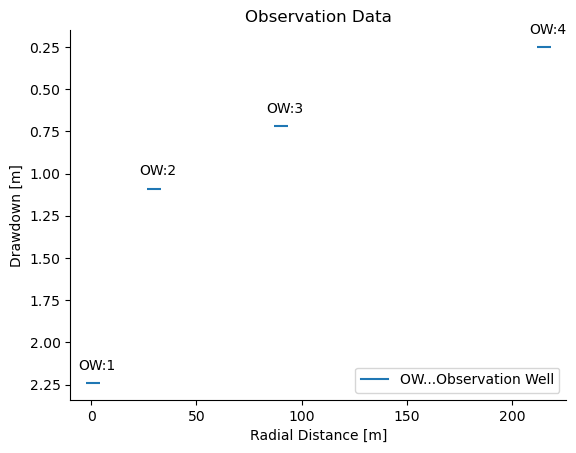

In [28]:
# Plot the Drawdown as funktion of the Radial Distance for the given Observation Data
fig, ax = plt.subplots()
df.plot(ax=ax, kind='scatter', x='Radial Distance', y='Drawdown', marker='_', s=100)

# Annotation for each marker
for i in range(len(df)):
        R = df.loc[i, 'Radial Distance']
        D = df.loc[i, 'Drawdown']
        Num = str(df.loc[i, 'Observation Number'])
        txt = 'OW:{}'.format(Num)
        ax.annotate(txt,(R,D),(R-7,D-0.08))

# Costum legent
handles, labels = plt.gca().get_legend_handles_labels()
line = matplotlib.lines.Line2D([0],[0], label='OW...Observation Well')
handles.extend([line])
plt.legend(handles=handles, loc='lower right')

# Format for the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Drawdown [m]')
ax.set_xlabel('Radial Distance [m]')
plt.title('Observation Data')
plt.gca().invert_yaxis()
plt.show()

<a id='ID2'></a>
## 2. Transmissitivity for an Unconfined Aquifer

<a id='ID21'></a>
### 2.1. Calculate Transmissitivity for an Unconfined Aquifer

$$ T = \frac{Q*ln (\frac{r_2}{r_1})}{2*\pi*(s_1-s_2)}$$

$T$...Transmissitivity [L²/T] <br>
$Q$...Constant Pumping Rate [L³/T] <br>
$r_1,r_2$... Radial distances to the osvervation wells [L] <br>
$s_1,s_2$... Drawdown [L] <br>

In [29]:
def calc_T(Q, dataframe=df, printdata=True):
    ''' 
    Calculate the Transmissitivity T for an Unconfined Aquifer.
    input:
        Q...int: Constant Pumping Rate [L³/T]
        dataframe...pd.dataframe: Data for Radial Distance [m] and Drawdown [m] of multible Observation Points
        printdata...bool
    output:
        T...Transmissitivity [L²/T]
    '''
    T_values = []
    for i in range(len(df) - 1):
        O1 = df.loc[i, 'Observation Number']
        O2 = df.loc[i + 1, 'Observation Number']
        R1 = df.loc[i, 'Radial Distance']
        R2 = df.loc[i + 1, 'Radial Distance']
        D1 = df.loc[i, 'Drawdown']
        D2 = df.loc[i + 1, 'Drawdown']
        
        T = (Q * np.log(R2 / R1)) / (2 * np.pi * (D1 - D2))
        if printdata == True:
            print('T({}/{}) = {:.4f} [m²/d]'.format(O1,O2,T))
        T_values.append(T)
    
    return np.array(T_values)

# Display the output
out_T = widgets.interactive_output(calc_T,{'Q':Q})
display(Q)
display(out_T)
        

IntSlider(value=778, description='Q [m³/d]', max=1000, min=1)

Output()

<a id='ID22'></a>
### 2.2. Plot Transmissitivity for an Unconfined Aquifer

In [45]:
def plot_T(Q, dataframe=df, printdata=False):
    ''' 
    Plot the Transmissitivity as calculated above
    input:
        Q...int: Constant Pumping Rate [L³/T]
        dataframe...pd.dataframe: Data for Radial Distance [m] and Drawdown [m] of multible Observation Points
        printdata...bool
    output:
        T...Transmissitivity [L²/T]
    '''
    fig, ax1 = plt.subplots()

    T=calc_T(Q, dataframe=df, printdata=False)

    TickLabels=[]
    bar_width=[]
    x_values=[]

    for i in range(len(df)-1):
        O1 = str(df.loc[i, 'Observation Number'])
        O2 = str(df.loc[i + 1, 'Observation Number'])
        O12 = '{}/{}'.format(O1,O2)
        TickLabels.append(O12)
        
        x1 = df.loc[i, 'Radial Distance']
        x2 = df.loc[i + 1, 'Radial Distance']
        x12 = x1+((x2-x1)/2)
        x_values.append(x12)

        w = x2-x1-2
        bar_width.append(w)

        
    ax2=ax1.twinx()

    # ax1: Transmissitivity
    ax1.bar(x=x_values, height=T, width=bar_width, color='lightblue', edgecolor='lightblue')
    ax1.set_ylim(0,500)
    ax1.set_ylabel('Transmissitivity [m²/d]')
    ax1.set_xlabel('Radial Distance [m]')
    ax1.spines['top'].set_visible(False)
    for i in range(len(df)-1):
        string ='T({})'.format(TickLabels[i])
        x1 = df.loc[i, 'Radial Distance']
        x2 = df.loc[i + 1, 'Radial Distance']
        loc=np.array(x1+((x2-x1)/2), T[i]/2)
        #ax1.annotate(string, xy=loc)

    # ax2: Observation Points
    df.plot(ax=ax2, kind='scatter', x='Radial Distance', y='Drawdown', marker='_', s=100)

    ## Annotation for each marker
    for i in range(len(df)):
        R = df.loc[i, 'Radial Distance']
        D = df.loc[i, 'Drawdown']
        Num = str(df.loc[i, 'Observation Number'])
        txt = 'OW:{}'.format(Num)
        ax2.annotate(txt,(R,D),(R-7,D-0.08))

    ax2.invert_yaxis()
    ax2.spines['top'].set_visible(False)

    ## Costum legent
    handles, labels = plt.gca().get_legend_handles_labels()
    line = matplotlib.lines.Line2D([0],[0], label='OW...Observation Well')
    handles.extend([line])
    plt.legend(handles=handles, loc='best')

    '''
    df.plot(ax=ax2, kind='scatter', x='Radial Distance', y='Drawdown')
    ax2.set_ylabel('Drawdown [m]')
    ax2.invert_yaxis()
    '''

    plt.title('Transmissitivity for an Unconfined Aquifer')

    plt.show()

out_T_plot = widgets.interactive_output(plot_T,{'Q':Q})
display(Q)
display(out_T_plot)

IntSlider(value=778, description='Q [m³/d]', max=1000, min=1)

Output()

<a id='ID3'></a>
## 3. Hydraulic Conductivity for a Confined Aquifer

<a id='ID31'></a>
### 3.1. Calculate Hydraulic Conductivity for a Confined Aquifer


<figure>
    <img src="pumping_confined.png" width="600" align='left' title='Fig1: Pumping and Observation Wells for a confined aquifer' >
    <figcaption>Fig1: Pumping and Observation Wells for a confined aquifer</figcaption>
</figure>

$$ K = \frac{Q*ln \frac{r_2}{r_1}}{2*\pi*(s_1^2-s_2^2)} $$

$K$...Hydraulic Conductivity [L/T] <br>
$Q$...Constant Pumping Rate [L³/T] <br>
$r_1,r_2$... Radial distances to the osvervation wells [L] <br>
$s_1,s_2$... Abstrich [L] <br>

In [31]:
def calc_K(Q, dataframe=df, printdata=True):
    ''' 
    Calculate the Hydraulic Conductivity K for a Confined Aquifer.
    input:
        Q...int: Constant Pumping Rate [L³/T]
        dataframe...pd.dataframe: Data for Radial Distance [m] and Drawdown [m] of multible Observation Points
        printdata...bool
    output:
        K...Hydraulic Conductivity [L/T]
    '''
    K_values = []
    for i in range(len(df) - 1):
        O1 = df.loc[i, 'Observation Number']
        O2 = df.loc[i + 1, 'Observation Number']
        R1 = df.loc[i, 'Radial Distance']
        R2 = df.loc[i + 1, 'Radial Distance']
        D1 = df.loc[i, 'Drawdown']
        D2 = df.loc[i + 1, 'Drawdown']
        
        K = (Q * np.log(R2 / R1)) / (2 * np.pi * (D1**2 - (D2**2)))
        print('K({}/{}) = {:.4f} [m/d]'.format(O1,O2,K))
        K_values.append(K)
    
    return np.array(K_values)

out_K = widgets.interactive_output(calc_K,{'Q':Q})
display(Q)
display(out_K)
        

IntSlider(value=778, description='Q [m³/d]', max=1000, min=1)

Output()

<a id='ID32'></a>
### 3.2. Plot Hydraulic Conductivity for a Confined Aquifer

In [ ]:
def plot_K(Q, dataframe=df, printdata=False):
    ''' 
    Plot the Hydraulic Conductivity K for a Confined Aquifer as calculated above.
    input:
        Q...int: Constant Pumping Rate [L³/T]
        dataframe...pd.dataframe: Data for Radial Distance [m] and Drawdown [m] of multible Observation Points.
        printdata...bool
    output:
        Plot for the Hydraulic Conductivity.
    '''



<a id='ID4'></a>
## 4. Radius of the Drawdown Cone

<a id='ID41'></a>
### 4.1. Calculate the Radius of the Drawdown Cone

transformation of formula (1)
$$ r_2 = e^{\frac{T*2*\pi*(s_1-s_2)}{Q}}*r_1 $$

$T$...Transmissivity [L²/T] <br>
$Q$...Constant Pumping Rate [L³/T] <br>
$r_1,r_2$... Radial distances to the osvervation wells [L] <br>
$s_1,s_2$... Abstrich [L] <br>

Where s_1,r_1 are data from the observation wells, s_2 is 0 (because it represents the edge of the drawdown cone) and r_2 is what we want to know (the radius of the drawdown cone)

$$ R = e^{\frac{T*2*\pi*(s)}{Q}}*r $$



In [32]:
def calc_R(Q, dataframe=df, printdata=True):
    ''' 
    Calculate the Drawdown Radius R for an Unconfined Aquifer.
    input:
        Q...int: Constant Pumping Rate [L³/T]
        dataframe...pd.dataframe: Data for Radial Distance [m] and Drawdown [m] of multible Observation Points
        printdata...bool
    output:
        R...Radius of the Drawdown cone [L]
    '''
    R_values = []
    T = calc_T(Q,df,False)
    T_mean = np.mean(T)

    for i in range(len(df) - 1):
        O1 = df.loc[i, 'Observation Number']
        R1 = df.loc[i, 'Radial Distance']
        D1 = df.loc[i, 'Drawdown']
    
        R = np.exp((T_mean*2*np.pi*D1)/Q)*R1
        print('R({}) = {:.4f} [m]'.format(O1,R))
        R_values.append(R)
    
    return np.array(R_values)

out_R = widgets.interactive_output(calc_R,{'Q':Q})
display(Q)
display(out_R)

IntSlider(value=778, description='Q [m³/d]', max=1000, min=1)

Output()

### 4.1. Plot the Radius of the Drawdown Cone

In [ ]:
def plot_R(Q, dataframe=df, printdata=False):
    ''' 
    Calculate the Drawdown Radius R for an Unconfined Aquifer.
    input:
        Q...int: Constant Pumping Rate [L³/T]
        dataframe...pd.dataframe: Data for Radial Distance [m] and Drawdown [m] of multible Observation Points
        printdata...bool
    output:
        R...Radius of the Drawdown cone [L]
    '''